Reading file: /Users/xylu/Desktop/Data/ahfb_local/LERDH_01_Feb_2026_18_57_13.igp...
Data loaded: 327678 points.
Y Range (mm): Min=-2.0971, Max=2.6214
Generating plot...
DONE. Plot saved to: beam_deviation_simple.png


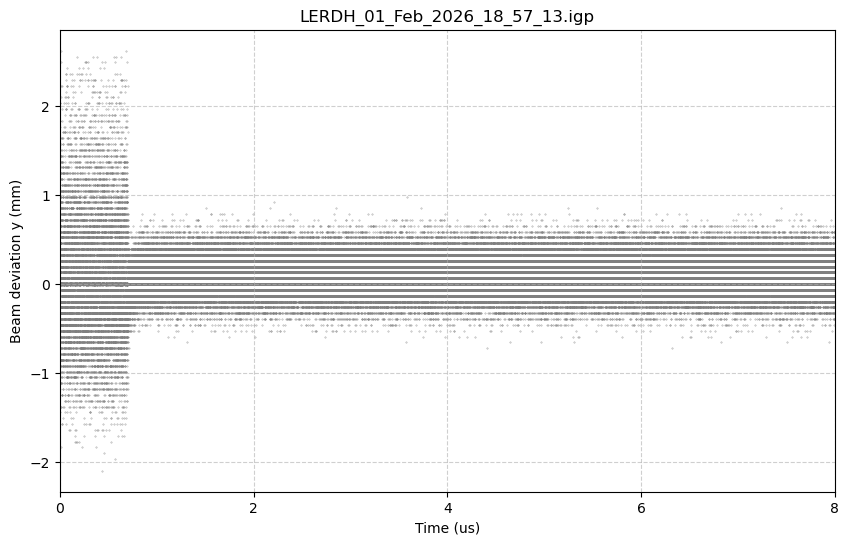

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def read_igp_binary(filename):
    """
    Reads .igp file assuming 4-byte header + 24-bit signed integers (Little Endian).
    """
    try:
        with open(filename, 'rb') as f:
            data = f.read()
            
        # Skip 4-byte header
        raw_bytes = data[4:]
        
        # Calculate number of full 3-byte samples
        n_samples = len(raw_bytes) // 3
        
        if n_samples == 0:
            return None
            
        # Extract valid bytes
        valid_raw = raw_bytes[:n_samples*3]
        bytes_array = np.frombuffer(valid_raw, dtype=np.uint8)
        
        # Reshape to (N, 3)
        bytes_reshaped = bytes_array.reshape(-1, 3)
        
        # Convert to 32-bit int for calculation
        b0 = bytes_reshaped[:, 0].astype(np.int32)
        b1 = bytes_reshaped[:, 1].astype(np.int32)
        b2 = bytes_reshaped[:, 2].astype(np.int32)
        
        # Combine: LSB + Mid + MSB
        combined = b0 | (b1 << 8) | (b2 << 16)
        
        # Handle 24-bit Sign Extension
        combined = np.where(combined & 0x800000, combined - 0x1000000, combined)
        
        return combined
        
    except Exception as e:
        print(f"Error reading binary file: {e}")
        return None

def create_plot(filename):
    # 1. Load Data
    print(f"Reading file: {filename}...")
    raw_y = read_igp_binary(filename)
    
    if raw_y is None or len(raw_y) == 0:
        print("ERROR: No data found in file.")
        return

    print(f"Data loaded: {len(raw_y)} points.")

    # 2. Scaling
    # Converting counts to mm (Assumption: 1 count = 1 nm -> 0.000001 mm)
    y = raw_y * 0.000001 
    
    # DEBUG: Print range to ensure values make sense
    print(f"Y Range (mm): Min={np.min(y):.4f}, Max={np.max(y):.4f}")

    # 3. Time Axis
    total_time = 9
    x = np.linspace(0, total_time, len(y))

    # 4. Plotting
    print("Generating plot...")
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # --- Plot ---
    ax.set_title(os.path.basename(filename))
    
    # CRITICAL FIX: rasterized=True prevents OverflowError/Memory crashes for large data
    ax.scatter(x, y, color='grey', marker = "o",alpha=0.8, s=0.1, rasterized=True)
    
    ax.set_ylabel('Beam deviation y (mm)')
    ax.set_xlabel('Time (us)')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.set_xlim(0, 2)
    ax.set_xticks(np.arange(0, 9, 2))

    plt.subplots_adjust(hspace=0.05)
    
    output_filename = "beam_deviation_simple.png"
    plt.savefig(output_filename, dpi=150, bbox_inches='tight')
    print(f"DONE. Plot saved to: {output_filename}")
    plt.show()

# --- Run ---
# Update this path to your specific file location
file_path = "/Users/xylu/Desktop/Data/ahfb_local/LERDH_01_Feb_2026_18_57_13.igp" 
create_plot(file_path)